# B6  Per-Prediction Reasoning
For each detection the model produces, we extract a structured explanation:
- What class was detected and with what confidence
- Where in the image (bounding box)
- Whether the detection triggers a violation
- A human-readable reasoning string


In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')


## Load Model and Paths


In [2]:
MODEL_PATH = Path("../model/best.pt")
TEST_DIR   = Path(r'../data/helmet-detection/test/images')

model = YOLO(str(MODEL_PATH))
CLASS_NAMES = model.names

test_images = sorted(TEST_DIR.glob('*.jpg'))[:20]
print(f'Model loaded. Classes: {CLASS_NAMES}')
print(f'Test images: {len(test_images)}')


Model loaded. Classes: {0: 'Helmet', 1: 'Motorbike', 2: 'NoHelmet', 3: 'PNumber'}
Test images: 20


## Per-Prediction Reasoning Function
For each bounding box the model returns, we build a reasoning string.


In [3]:
def reason_for_detection(cls_name, conf, box_xyxy):
    x1, y1, x2, y2 = [int(v) for v in box_xyxy]
    cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
    size = (x2 - x1) * (y2 - y1)
    conf_label = 'high' if conf >= 0.75 else ('medium' if conf >= 0.5 else 'low')

    if cls_name == 'Helmet':
        action = 'No violation — rider is wearing a helmet.'
    elif cls_name == 'NoHelmet':
        action = 'VIOLATION — rider has no helmet. Flag for enforcement.'
    elif cls_name == 'Motorbike':
        action = 'Motorcycle detected — used to associate rider.'
    elif cls_name == 'PNumber':
        action = 'License plate detected — candidate for OCR.'
    else:
        action = 'Unknown class.'

    return (f'[{cls_name}] conf={conf:.2f} ({conf_label}) | '
            f'center=({cx},{cy}) | area={size}px | {action}')


def analyze_image(img_path):
    results = model(str(img_path), verbose=False)[0]
    records = []
    for box in results.boxes:
        cls_id   = int(box.cls[0])
        cls_name = CLASS_NAMES[cls_id]
        conf     = float(box.conf[0])
        xyxy     = box.xyxy[0].tolist()
        records.append({
            'image':     img_path.name,
            'class':     cls_name,
            'confidence': round(conf, 4),
            'x1': int(xyxy[0]), 'y1': int(xyxy[1]),
            'x2': int(xyxy[2]), 'y2': int(xyxy[3]),
            'violation': cls_name == 'NoHelmet',
            'reasoning': reason_for_detection(cls_name, conf, xyxy)
        })
    return records

print('Functions defined.')


Functions defined.


## Run Reasoning on 20 Test Images


In [4]:
all_records = []
for img_path in test_images:
    all_records.extend(analyze_image(img_path))

df = pd.DataFrame(all_records)
print(f'Total detections: {len(df)}')
print(f'Violations flagged: {df["violation"].sum()}')
print(f'Images with violations: {df[df["violation"]]["image"].nunique()}')
df.head(10)


Total detections: 68
Violations flagged: 20
Images with violations: 10


,image,class,confidence,x1,y1,x2,y2,violation,reasoning
0,102_jpeg_jpg.rf.baf9afb3d168866a01361b12b40771...,PNumber,0.8383,160,349,258,407,False,"[PNumber] conf=0.84 (high) | center=(209,378) ..."
1,102_jpeg_jpg.rf.baf9afb3d168866a01361b12b40771...,Motorbike,0.8336,130,197,320,640,False,"[Motorbike] conf=0.83 (high) | center=(225,418..."
2,102_jpeg_jpg.rf.baf9afb3d168866a01361b12b40771...,Helmet,0.8205,173,56,228,128,False,"[Helmet] conf=0.82 (high) | center=(200,92) | ..."
3,102_jpeg_jpg.rf.baf9afb3d168866a01361b12b40771...,NoHelmet,0.7942,245,67,311,181,True,"[NoHelmet] conf=0.79 (high) | center=(278,124)..."
4,102_jpeg_jpg.rf.baf9afb3d168866a01361b12b40771...,Motorbike,0.7920,57,173,166,415,False,"[Motorbike] conf=0.79 (high) | center=(111,294..."
5,102_jpeg_jpg.rf.baf9afb3d168866a01361b12b40771...,Motorbike,0.6963,230,480,586,640,False,"[Motorbike] conf=0.70 (medium) | center=(408,5..."
6,102_jpeg_jpg.rf.baf9afb3d168866a01361b12b40771...,Motorbike,0.4032,0,514,115,640,False,"[Motorbike] conf=0.40 (low) | center=(57,577) ..."
7,102_jpeg_jpg.rf.baf9afb3d168866a01361b12b40771...,PNumber,0.3658,83,259,124,287,False,"[PNumber] conf=0.37 (low) | center=(103,273) |..."
8,104_jpg.rf.907fe162311a0a7f405cab3899404a9f.jpg,Motorbike,0.9078,159,336,430,505,False,"[Motorbike] conf=0.91 (high) | center=(294,420..."
9,104_jpg.rf.907fe162311a0a7f405cab3899404a9f.jpg,NoHelmet,0.7582,331,303,374,340,True,"[NoHelmet] conf=0.76 (high) | center=(352,321)..."


## Print Reasoning Strings for 3 Sample Images


In [5]:
sample_images = df['image'].unique()[:3]
for img_name in sample_images:
    subset = df[df['image'] == img_name]
    verdict = 'VIOLATION' if subset['violation'].any() else 'CLEAR'
    print(f'\n=== {img_name} === [{verdict}]')
    for _, row in subset.iterrows():
        print(' ', row['reasoning'])



=== 102_jpeg_jpg.rf.baf9afb3d168866a01361b12b4077139.jpg === [VIOLATION]
  [PNumber] conf=0.84 (high) | center=(209,378) | area=5684px | License plate detected — candidate for OCR.
  [Motorbike] conf=0.83 (high) | center=(225,418) | area=84170px | Motorcycle detected — used to associate rider.
  [Helmet] conf=0.82 (high) | center=(200,92) | area=3960px | No violation — rider is wearing a helmet.
  [NoHelmet] conf=0.79 (high) | center=(278,124) | area=7524px | VIOLATION — rider has no helmet. Flag for enforcement.
  [Motorbike] conf=0.79 (high) | center=(111,294) | area=26378px | Motorcycle detected — used to associate rider.
  [Motorbike] conf=0.70 (medium) | center=(408,560) | area=56960px | Motorcycle detected — used to associate rider.
  [Motorbike] conf=0.40 (low) | center=(57,577) | area=14490px | Motorcycle detected — used to associate rider.
  [PNumber] conf=0.37 (low) | center=(103,273) | area=1148px | License plate detected — candidate for OCR.

=== 104_jpg.rf.907fe162311a0a7

## Visualise Violation vs Clear Images


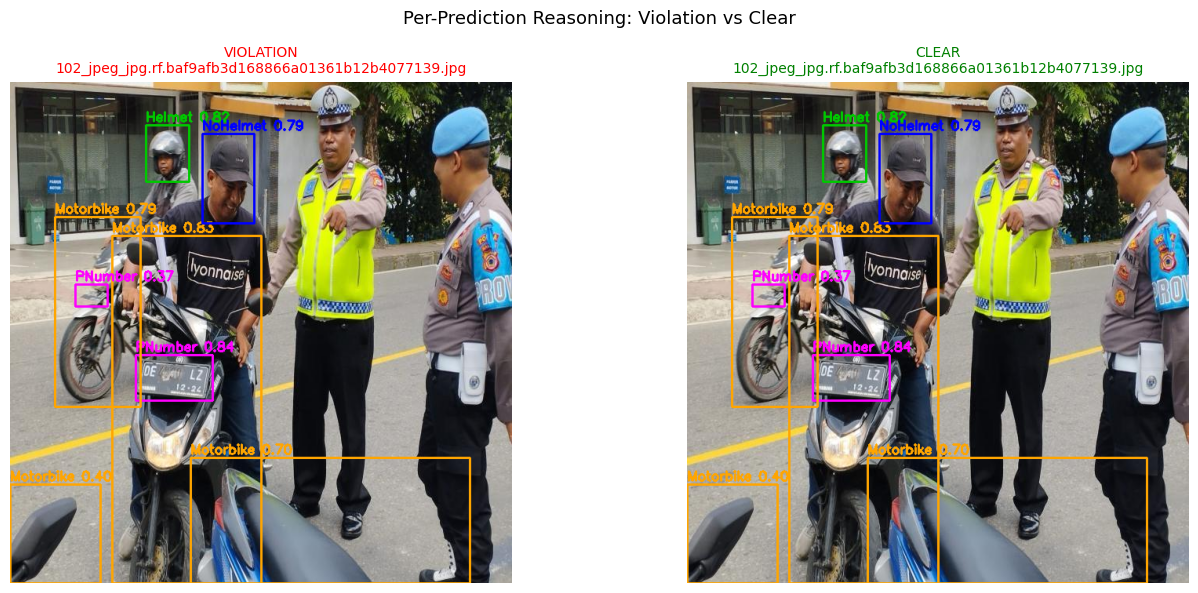

In [6]:
violation_imgs = df[df['violation']]['image'].unique()
clear_imgs     = df[~df['violation']]['image'].unique()

COLOR_MAP = {'Helmet': (0,200,0), 'NoHelmet': (0,0,255),
             'Motorbike': (255,165,0), 'PNumber': (255,0,255)}

def draw_reasoning(img_path, records):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for r in records:
        color = COLOR_MAP.get(r['class'], (128,128,128))
        cv2.rectangle(img, (r['x1'],r['y1']), (r['x2'],r['y2']), color, 2)
        label = f"{r['class']} {r['confidence']:.2f}"
        cv2.putText(img, label, (r['x1'], max(r['y1']-5,10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    return img

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if len(violation_imgs) > 0:
    vimg  = TEST_DIR / violation_imgs[0]
    vrecs = df[df['image'] == violation_imgs[0]].to_dict('records')
    axes[0].imshow(draw_reasoning(vimg, vrecs))
    axes[0].set_title(f'VIOLATION\n{violation_imgs[0]}', color='red', fontsize=10)
    axes[0].axis('off')

if len(clear_imgs) > 0:
    cimg  = TEST_DIR / clear_imgs[0]
    crecs = df[df['image'] == clear_imgs[0]].to_dict('records')
    axes[1].imshow(draw_reasoning(cimg, crecs))
    axes[1].set_title(f'CLEAR\n{clear_imgs[0]}', color='green', fontsize=10)
    axes[1].axis('off')

plt.suptitle('Per-Prediction Reasoning: Violation vs Clear', fontsize=13)
plt.tight_layout()
plt.savefig('b6_reasoning_viz.png', dpi=150)
plt.show()


## Detection Summary Table


In [7]:
summary = df.groupby('class').agg(
    count=('class', 'count'),
    mean_conf=('confidence', 'mean'),
    violations=('violation', 'sum')
).round(4).reset_index()
print(summary.to_string(index=False))

img_summary = df.groupby('image')['violation'].any().reset_index()
img_summary.columns = ['image', 'has_violation']
n_viol  = img_summary['has_violation'].sum()
n_clear = (~img_summary['has_violation']).sum()
print(f'\nOut of {len(img_summary)} images: {n_viol} violations, {n_clear} clear')


    class  count  mean_conf  violations
   Helmet     15     0.7469           0
Motorbike     26     0.7925           0
 NoHelmet     20     0.7388          20
  PNumber      7     0.5360           0

Out of 18 images: 10 violations, 8 clear


## Summary
- Each bounding box prediction is explained with: class, confidence level (high/medium/low), position, and enforcement action.
- A detection is flagged as a **violation** only when `class == NoHelmet`.
- The reasoning strings mirror the logic used in the FastAPI endpoint to produce the `violation` field in the API response.
- This per-prediction transparency allows enforcement officers to understand exactly why an image was flagged.
